# **CONSUMO ABUSIVO DE SPA EN JOVENES DE BOGOTA: UN ANALISIS SOCIODEMOGRAFICO DESDE LOS DATOS DE VESPA (2019 - 2026)**

**Integrantes:**

Sara Gabriela Cajamarca Lozano

Santiago Herrera Leon

Raul Felipe Ropero Barbosa

Dumar Alexis Ruiz Bernal

Valeria Velez Molina

---

**PREGUNTA PROBLEMA**

¿Qué características sociodemográficas y de contexto (lugar habitual de consumo, nivel educativo, aseguramiento en salud) predominan en los casos de consumo abusivo de sustancias psicoactivas en adolescentes y jóvenes de Bogotá, reportados al sistema VESPA entre 2019 y 2026?

**PREGUNTAS DE APOYO**

1. ¿Cómo se distribuyen los casos de consumo abusivo de SPA en adolescentes y jóvenes según la localidad de residencia en Bogotá?
2. ¿Cómo ha evolucionado el número de casos reportados en jóvenes a lo largo de los años del periodo (2019-2026)?
3. ¿Qué diferencias hay entre hombres y mujeres jóvenes en el número de casos reportados?
4. ¿En qué lugares habituales de consumo se concentran más los casos de jóvenes?
5. ¿Qué relación existe entre el nivel educativo de los jóvenes y el tipo de aseguramiento en salud de los casos reportados?

**PREGUNTA DEL MODELO PREDICTIVO**

A partir del perfil sociodemográfico de un caso (sexo, nivel educativo, tipo de aseguramiento, lugar habitual de consumo y año). ¿Es posible predecir si ese caso proviene de una localidad de alto riesgo (Kennedy, Bosa, Suba, Ciudad Bolívar o Engativá, las cinco localidades con más casos)?


# **1. BUSQUEDA Y OPTENCION DE DATOS**

**Fuente:** Secretaría Distrital de Salud de Bogotá, subsistema VESPA (Vigilancia Epidemiológica del Consumo de Sustancias Psicoactivas), publicado en el portal de Datos Abiertos Bogotá / Observatorio SaluData.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import scipy.stats as st

In [2]:
sns.set_style('whitegrid')
pd.set_option('display.max_columns', 30)

df = pd.read_csv('osb_saludmental_-consumoabusivo_spageneral.csv', sep=';', encoding='utf-8-sig')
df.head(10)

,ANO,SEXO,NOMBRELOCALIDADRESIDENCIA,MESNOTIFICACION,TRIMESTRE,TIPOASEGURAMIENTO,SITIOHABITUALCONSUMO_VIVIENDA,SITIOHABITUALCONSUMO_PARQUE,SITIOHABITUALCONSUMO_EST_EDUCATIVO,SITIOHABITUALCONSUMO_BARES_TABERNAS,SITIOHABITUALCONSUMO_VIA_PUBLICA,SITIOHABITUALCONSUMO_CASA_AMIGOS,NIVELEDUCATIVO,CURSO_DE_VIDA,COMOACUDIOTRATAMIENTO,PERTENENCIAETNICA,ORIENTSEXUAL,PAISNACIONALIDAD,NOMBREUPZ,ESTADOCIVIL,CASOS
0,2022,Hombre,Kennedy,6,2,Subsidiado,NO,NO,NO,NO,SI,SI,Secundaria completa,Juventud,Voluntariamente,Otros,Heterosexual,Sin Dato,AMERICAS,Soltero (a),1
1,2022,Hombre,Mártires,6,2,Subsidiado,SI,NO,NO,NO,NO,NO,Secundaria completa,Adultez,Voluntariamente,Otros,Heterosexual,Sin Dato,LA SABANA,Soltero (a),2
2,2022,Hombre,Kennedy,6,2,Contributivo,NO,SI,SI,NO,NO,NO,Secundaria incompleta,Adolescencia,Voluntariamente,Otros,Heterosexual,Sin Dato,CALANDAIMA,Soltero (a),1
3,2022,Hombre,Kennedy,6,2,Contributivo,NO,NO,NO,NO,SI,SI,Secundaria completa,Juventud,Voluntariamente,Otros,Heterosexual,Sin Dato,LAS MARGARITAS,Union libre,1
4,2022,Mujer,Kennedy,6,2,Contributivo,NO,NO,NO,NO,SI,SI,Secundaria completa,Adultez,Voluntariamente,Otros,Heterosexual,Sin Dato,LAS MARGARITAS,Soltero (a),1
5,2022,Hombre,Mártires,6,2,Subsidiado,NO,SI,NO,NO,NO,NO,Secundaria incompleta,Adultez,Voluntariamente,Otros,Heterosexual,Sin Dato,LA SABANA,Separado (a),1
6,2022,Hombre,Kennedy,6,2,Subsidiado,NO,SI,NO,NO,NO,NO,Secundaria completa,Juventud,Voluntariamente,Otros,Heterosexual,Sin Dato,LAS MARGARITAS,Union libre,1
7,2022,Hombre,Mártires,6,2,Subsidiado,NO,NO,NO,NO,SI,SI,Secundaria incompleta,Adultez,Voluntariamente,Otros,Heterosexual,Sin Dato,LA SABANA,Soltero (a),22
8,2022,Hombre,Sin dato,6,2,Subsidiado,NO,NO,NO,NO,SI,SI,Secundaria completa,Adultez,Voluntariamente,Otros,Heterosexual,Sin Dato,N.A.,Soltero (a),5
9,2022,Hombre,Mártires,6,2,Subsidiado,NO,NO,NO,NO,SI,SI,Primaria completa,Adultez,Voluntariamente,Otros,Heterosexual,Sin Dato,LA SABANA,Soltero (a),8


# **2. COMPRENSION DEL CONJUNTO DE DATOS**

- **Tamaño:** 101.500 filas, 21 columnas.
- **Unidad de análisis:** Una fila NO es una persona. Cada fila es una combinación de categorías (año, sexo, localidad, etc.) y la columna `CASOS` indica cuántos casos reales corresponden a esa combinación.
- **Variables clave:** año, sexo, localidad de residencia, tipo de aseguramiento, seis columnas SI/NO de lugar habitual de consumo, nivel educativo, curso de vida (grupo etario), pertenencia étnica, orientación sexual, país de nacionalidad, UPZ, estado civil y `CASOS`.

In [3]:
print("Filas:", df.shape[0], " Columnas:", df.shape[1])
print("\nNulos por columna:\n", df.isnull().sum())
print("\nDuplicados exactos:", df.duplicated().sum())
print("\nCategorías en CURSO_DE_VIDA:\n", df['CURSO_DE_VIDA'].value_counts())

Filas: 101500  Columnas: 21

Nulos por columna:
 ANO                                      0
SEXO                                    44
NOMBRELOCALIDADRESIDENCIA                0
MESNOTIFICACION                          0
TRIMESTRE                                0
TIPOASEGURAMIENTO                        0
SITIOHABITUALCONSUMO_VIVIENDA            0
SITIOHABITUALCONSUMO_PARQUE              0
SITIOHABITUALCONSUMO_EST_EDUCATIVO       0
SITIOHABITUALCONSUMO_BARES_TABERNAS      0
SITIOHABITUALCONSUMO_VIA_PUBLICA         0
SITIOHABITUALCONSUMO_CASA_AMIGOS         0
NIVELEDUCATIVO                           0
CURSO_DE_VIDA                            0
COMOACUDIOTRATAMIENTO                    0
PERTENENCIAETNICA                      106
ORIENTSEXUAL                             0
PAISNACIONALIDAD                         0
NOMBREUPZ                                0
ESTADOCIVIL                              0
CASOS                                    0
dtype: int64

Duplicados exactos: 0

Categorías 

# **3. LIMPIEZA Y PREPARACION DE LOS DATOS**

Se unifican las variantes de 'sin dato', se completan los nulos de SEXO y PERTENENCIAETNICA, y se filtra la base para quedarnos únicamente con adolescentes y jóvenes (variable `CURSO_DE_VIDA`) en el periodo 2019-2026, que es el foco de la pregunta problema.

In [4]:
valores_nulos_disfrazados = ['Sin dato', 'Sin Dato', 'SIN DATO', 'N.A.']
df_limpio = df.replace(valores_nulos_disfrazados, 'Sin dato')
df_limpio[['SEXO','PERTENENCIAETNICA']] = df_limpio[['SEXO','PERTENENCIAETNICA']].fillna('Sin dato')
print("Verificación NOMBRELOCALIDADRESIDENCIA:", df_limpio['NOMBRELOCALIDADRESIDENCIA'].unique())

Verificación NOMBRELOCALIDADRESIDENCIA: ['Kennedy' 'Mártires' 'Sin dato' 'Fontibón' 'Bosa' 'Puente Aranda'
 'Engativá' 'Santa Fe' 'Usme' 'Ciudad Bolívar' 'Teusaquillo' 'Tunjuelito'
 'San Cristóbal' 'Usaquén' 'Suba' 'Antonio Nariño' 'Chapinero'
 'Rafael Uribe' 'Candelaria' 'Barrios Unidos' 'Sumapaz']


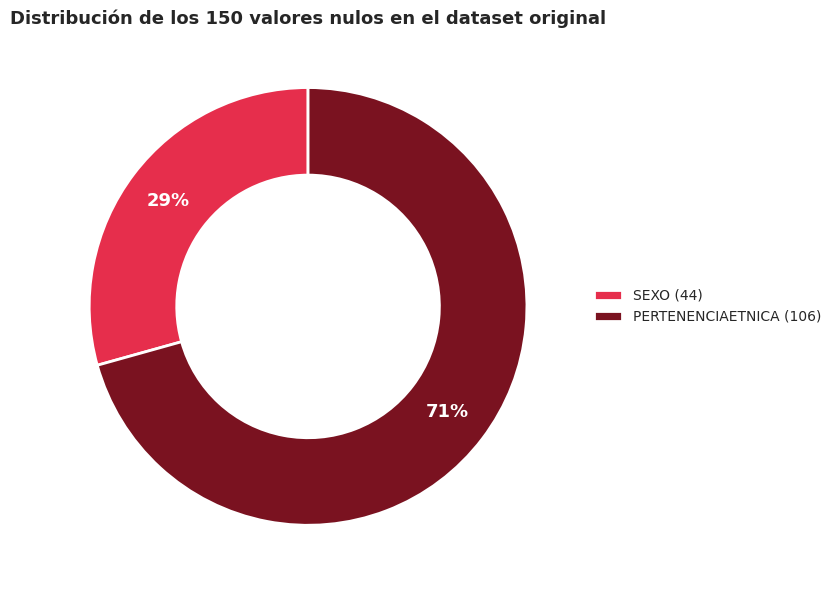

In [5]:
valores = [44, 106]
etiquetas = ['SEXO (44)', 'PERTENENCIAETNICA (106)']
colores = ['#E62E4C', '#7a1220']

fig, ax = plt.subplots(figsize=(8,6))
wedges, texts, autotexts = ax.pie(
    valores,
    colors=colores,
    autopct='%1.0f%%',
    startangle=90,
    pctdistance=0.8,
    wedgeprops={'width': 0.4, 'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 13, 'fontweight': 'bold', 'color': 'white'}
)

ax.legend(wedges, etiquetas, loc='center left', bbox_to_anchor=(1, 0.5), fontsize=10, frameon=False)
plt.title('Distribución de los 150 valores nulos en el dataset original', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [6]:
df_jovenes = df_limpio[
    (df_limpio['CURSO_DE_VIDA'].isin(['Adolescencia','Juventud'])) &
    (df_limpio['ANO'] >= 2019) & (df_limpio['ANO'] <= 2026)
].copy()

print("Filas totales limpias:", len(df_limpio))
print("Filas de jóvenes 2019-2026:", len(df_jovenes))
print("Total de casos (suma de CASOS):", df_jovenes['CASOS'].sum())

Filas totales limpias: 101500
Filas de jóvenes 2019-2026: 38585
Total de casos (suma de CASOS): 41345


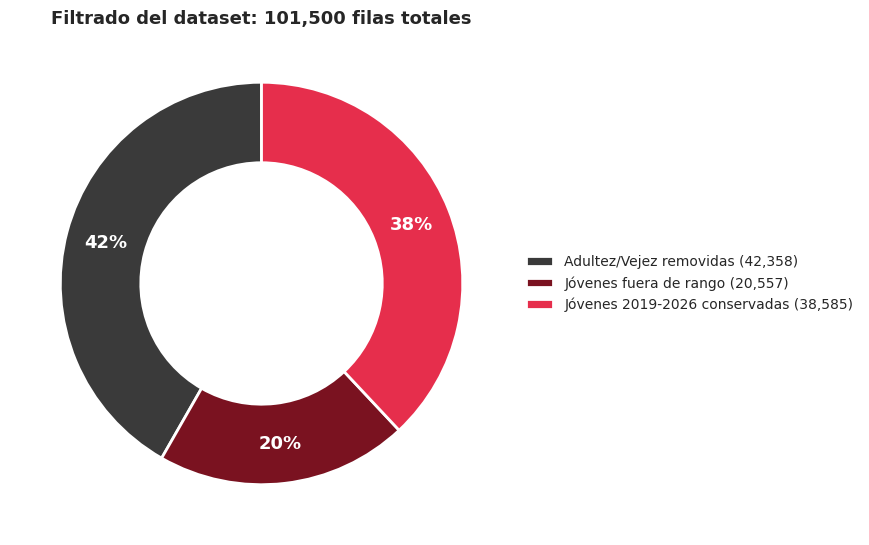

In [7]:
valores = [42358, 20557, 38585]
etiquetas = ['Adultez/Vejez removidas (42,358)', 'Jóvenes fuera de rango (20,557)', 'Jóvenes 2019-2026 conservadas (38,585)']
colores = ['#3a3a3a', '#7a1220', '#E62E4C']

fig, ax = plt.subplots(figsize=(8,6))
wedges, texts, autotexts = ax.pie(
    valores,
    colors=colores,
    autopct='%1.0f%%',
    startangle=90,
    pctdistance=0.8,
    wedgeprops={'width': 0.4, 'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 13, 'fontweight': 'bold', 'color': 'white'}
)

ax.legend(wedges, etiquetas, loc='center left', bbox_to_anchor=(1, 0.5), fontsize=10, frameon=False)
plt.title('Filtrado del dataset: 101,500 filas totales', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
comparacion = pd.DataFrame({
    "Antes (Datos Crudos)": [df.shape[0], df.isnull().sum().sum(), df.duplicated().sum()],
    "Después (Jovenes - Datos Limpios)": [len(df_jovenes), df_jovenes.isnull().sum().sum(), df_jovenes.duplicated().sum()]
}, index=["Filas", "Valores nulos", "Duplicados"])
comparacion

,Antes (Datos Crudos),Después (Jovenes - Datos Limpios)
Filas,101500,38585
Valores nulos,150,0
Duplicados,0,7


In [9]:
df_jovenes.sample(10, random_state=1)

,ANO,SEXO,NOMBRELOCALIDADRESIDENCIA,MESNOTIFICACION,TRIMESTRE,TIPOASEGURAMIENTO,SITIOHABITUALCONSUMO_VIVIENDA,SITIOHABITUALCONSUMO_PARQUE,SITIOHABITUALCONSUMO_EST_EDUCATIVO,SITIOHABITUALCONSUMO_BARES_TABERNAS,SITIOHABITUALCONSUMO_VIA_PUBLICA,SITIOHABITUALCONSUMO_CASA_AMIGOS,NIVELEDUCATIVO,CURSO_DE_VIDA,COMOACUDIOTRATAMIENTO,PERTENENCIAETNICA,ORIENTSEXUAL,PAISNACIONALIDAD,NOMBREUPZ,ESTADOCIVIL,CASOS
25823,2024,Mujer,Bosa,7,3,Vinculado,NO,NO,NO,NO,SI,SI,Secundaria incompleta,Juventud,Voluntariamente,Otros,Heterosexual,COLOMBIA,BOSA CENTRAL,Union libre,1
45817,2025,Hombre,Chapinero,10,4,Contributivo,SI,NO,NO,NO,NO,NO,Técnico post-secundaria completa,Juventud,Voluntariamente,Otros,Heterosexual,COLOMBIA,CHICO LAGO,Soltero (a),1
20858,2024,Hombre,Teusaquillo,3,1,Excepción,NO,NO,NO,SI,SI,SI,Técnico post-secundaria completa,Juventud,Lo llevaron familiares,Otros,Heterosexual,COLOMBIA,TEUSAQUILLO,Soltero (a),1
22509,2024,Hombre,Teusaquillo,4,2,Excepción,NO,SI,SI,NO,SI,SI,Secundaria incompleta,Adolescencia,Lo llevaron familiares,Otros,Heterosexual,COLOMBIA,TEUSAQUILLO,Soltero (a),1
52303,2026,Hombre,Ciudad Bolívar,5,2,Contributivo,NO,NO,NO,NO,SI,SI,Secundaria incompleta,Adolescencia,Indicación Medica,Otros,Heterosexual,COLOMBIA,ISMAEL PERDOMO,Soltero (a),1
5245,2022,Hombre,Kennedy,12,4,Contributivo,NO,NO,NO,NO,SI,SI,Secundaria incompleta,Juventud,Voluntariamente,Otros,Heterosexual,Sin dato,PATIO BONITO,Soltero (a),1
91826,2021,Mujer,Suba,7,3,Contributivo,SI,SI,NO,NO,SI,SI,Técnico post-secundaria completa,Juventud,Sin dato,Otros,Heterosexual,Sin dato,TIBABUYES,Soltero (a),1
81609,2020,Mujer,Tunjuelito,2,1,Subsidiado,NO,SI,NO,SI,SI,SI,Secundaria incompleta,Juventud,Voluntariamente,Otros,Heterosexual,Sin dato,VENECIA,Soltero (a),1
16997,2023,Hombre,Kennedy,9,3,Subsidiado,NO,SI,NO,SI,SI,SI,Universidad incompleta,Juventud,Sin dato,Otros,Heterosexual,COLOMBIA,LAS MARGARITAS,Soltero (a),1
23806,2024,Hombre,Engativá,5,2,Contributivo,NO,NO,NO,NO,SI,SI,Secundaria completa,Juventud,Sin dato,Otros,Heterosexual,COLOMBIA,EL MINUTO DE DIOS,Soltero (a),1


In [10]:
df_jovenes.to_csv('spa_jovenes_limpio.csv', index=False)
print("Archivo limpio guardado. Filas:", len(df_jovenes), " | Total casos:", df_jovenes['CASOS'].sum())

Archivo limpio guardado. Filas: 38585  | Total casos: 41345


# **4. ANALISIS EXPLORATORIO DE DATOS (EDA)**

Se responden las cinco preguntas de apoyo planteadas al inicio del proyecto.

###**Pregunta 1. Distribución de casos por localidad**

In [11]:
total_casos = df_jovenes['CASOS'].sum()

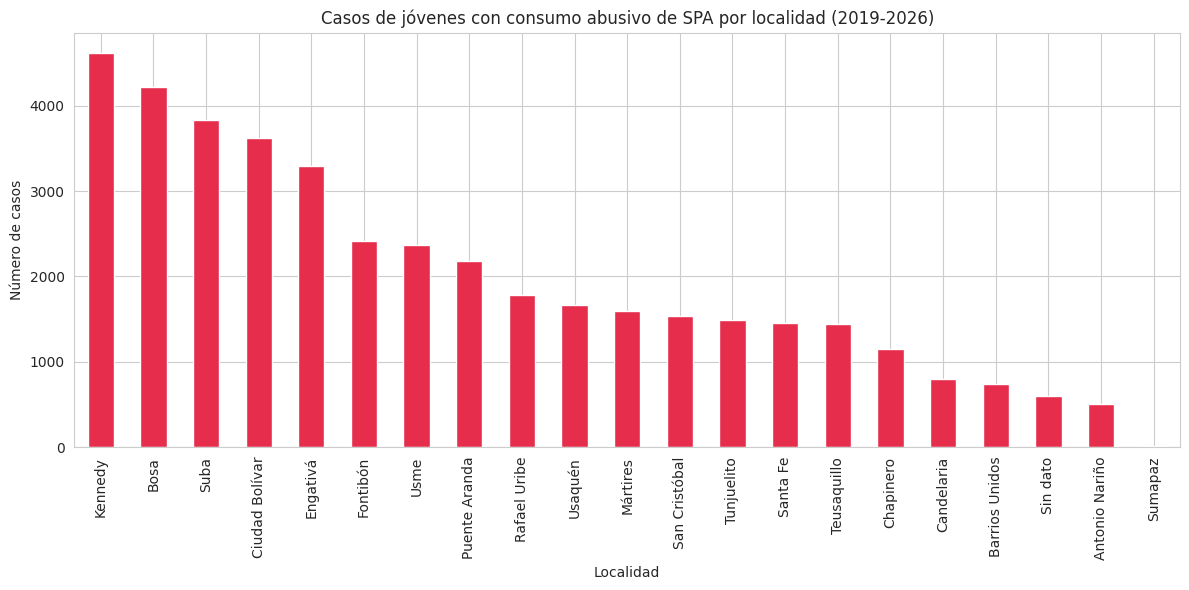

In [12]:
casos_localidad = df_jovenes.groupby('NOMBRELOCALIDADRESIDENCIA')['CASOS'].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))
casos_localidad.plot(kind='bar', color='#E62E4C')
plt.title('Casos de jóvenes con consumo abusivo de SPA por localidad (2019-2026)')
plt.xlabel('Localidad')
plt.ylabel('Número de casos')
plt.tight_layout()
plt.show()

In [13]:
print("-------------- Casos por localidad (%) --------------")
print(pd.DataFrame({'Casos': casos_localidad, 'Porcentaje (%)': (casos_localidad/total_casos*100).round(1)}))

-------------- Casos por localidad (%) --------------
                           Casos  Porcentaje (%)
NOMBRELOCALIDADRESIDENCIA                       
Kennedy                     4624            11.2
Bosa                        4223            10.2
Suba                        3829             9.3
Ciudad Bolívar              3628             8.8
Engativá                    3294             8.0
Fontibón                    2413             5.8
Usme                        2369             5.7
Puente Aranda               2182             5.3
Rafael Uribe                1787             4.3
Usaquén                     1662             4.0
Mártires                    1596             3.9
San Cristóbal               1541             3.7
Tunjuelito                  1492             3.6
Santa Fe                    1452             3.5
Teusaquillo                 1445             3.5
Chapinero                   1155             2.8
Candelaria                   802             1.9
Barrios Unidos 

###**Pregunta 2. Evolución de los casos por año**

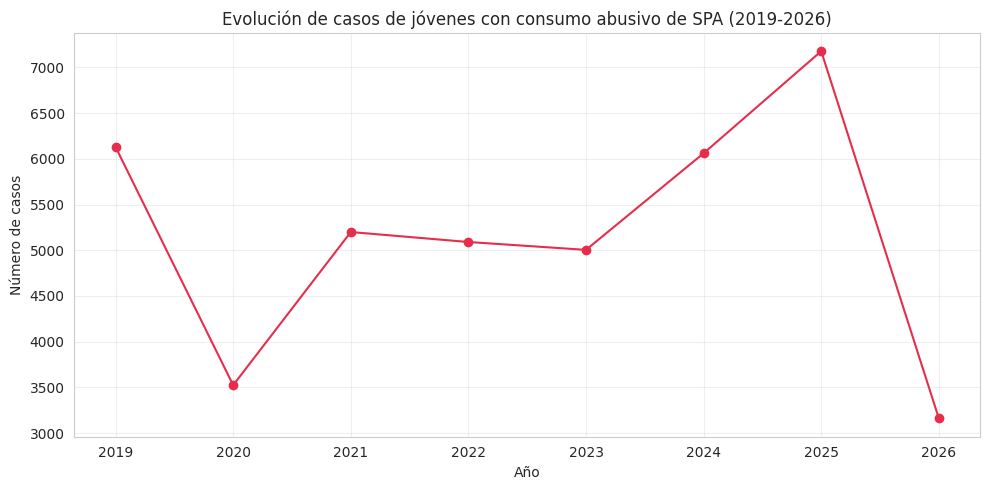

In [14]:
casos_anio = df_jovenes.groupby('ANO')['CASOS'].sum().sort_index()

plt.figure(figsize=(10,5))
casos_anio.plot(kind='line', marker='o', color='#E62E4C')
plt.title('Evolución de casos de jóvenes con consumo abusivo de SPA (2019-2026)')
plt.xlabel('Año')
plt.ylabel('Número de casos')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

###**Pregunta 3. Diferencias por sexo**

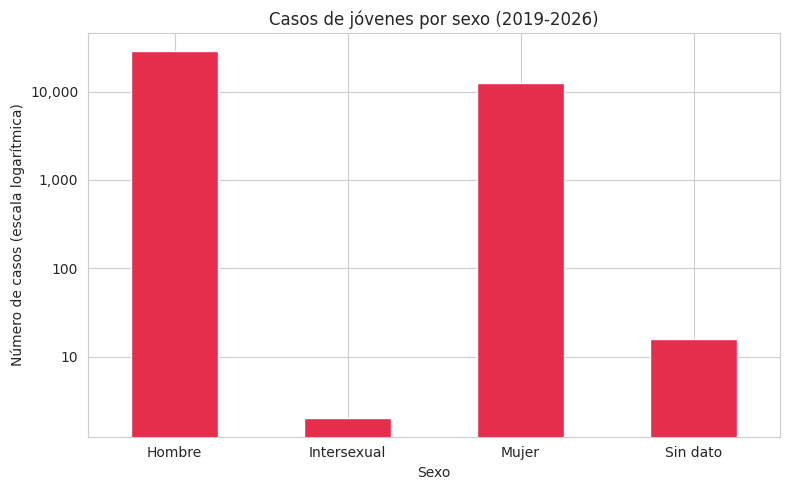

In [15]:
casos_sexo = df_jovenes.groupby('SEXO')['CASOS'].sum()

plt.figure(figsize=(8,5))
casos_sexo.plot(kind='bar', color=['#E62E4C'])
plt.title('Casos de jóvenes por sexo (2019-2026)')
plt.xlabel('Sexo')
plt.ylabel('Número de casos (escala logarítmica)')
plt.yscale('log')
plt.minorticks_off()
plt.xticks(rotation=0)
ax = plt.gca()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

In [16]:
print("---------- Casos por sexo (%) ----------")
print(pd.DataFrame({'Casos': casos_sexo, 'Porcentaje (%)': (casos_sexo/total_casos*100).round(1)}))

---------- Casos por sexo (%) ----------
             Casos  Porcentaje (%)
SEXO                              
Hombre       28679            69.4
Intersexual      2             0.0
Mujer        12648            30.6
Sin dato        16             0.0


###**Pregunta 4. Lugares habituales de consumo**

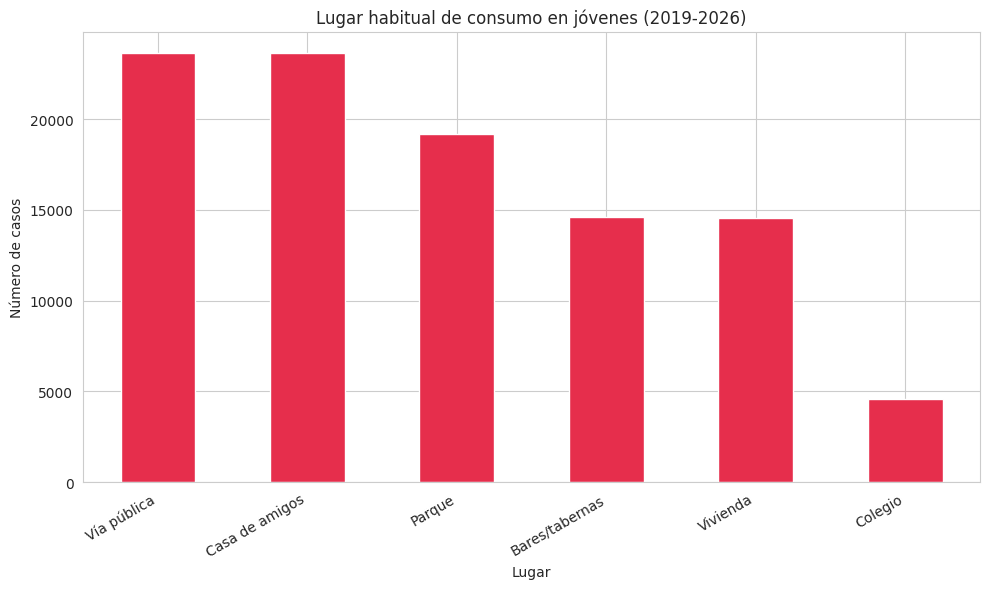

In [17]:
etiquetas_sitio = {
    'SITIOHABITUALCONSUMO_VIVIENDA': 'Vivienda',
    'SITIOHABITUALCONSUMO_PARQUE': 'Parque',
    'SITIOHABITUALCONSUMO_EST_EDUCATIVO': 'Colegio',
    'SITIOHABITUALCONSUMO_BARES_TABERNAS': 'Bares/tabernas',
    'SITIOHABITUALCONSUMO_VIA_PUBLICA': 'Vía pública',
    'SITIOHABITUALCONSUMO_CASA_AMIGOS': 'Casa de amigos'
}

totales_sitio = {}
for col, etiqueta in etiquetas_sitio.items():
    totales_sitio[etiqueta] = df_jovenes.loc[df_jovenes[col] == 'SI', 'CASOS'].sum()

serie_sitio = pd.Series(totales_sitio).sort_values(ascending=False)

plt.figure(figsize=(10,6))
serie_sitio.plot(kind='bar', color='#E62E4C')
plt.title('Lugar habitual de consumo en jóvenes (2019-2026)')
plt.xlabel('Lugar')
plt.ylabel('Número de casos')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [18]:
print("----- Casos por lugar de consumo (%) -----")
print(pd.DataFrame({'Casos': serie_sitio, 'Porcentaje (%)': (serie_sitio/total_casos*100).round(1)}))

----- Casos por lugar de consumo (%) -----
                Casos  Porcentaje (%)
Vía pública     23635            57.2
Casa de amigos  23635            57.2
Parque          19167            46.4
Bares/tabernas  14633            35.4
Vivienda        14575            35.3
Colegio          4590            11.1


###**Pregunta 5. Nivel educativo vs. tipo de aseguramiento**

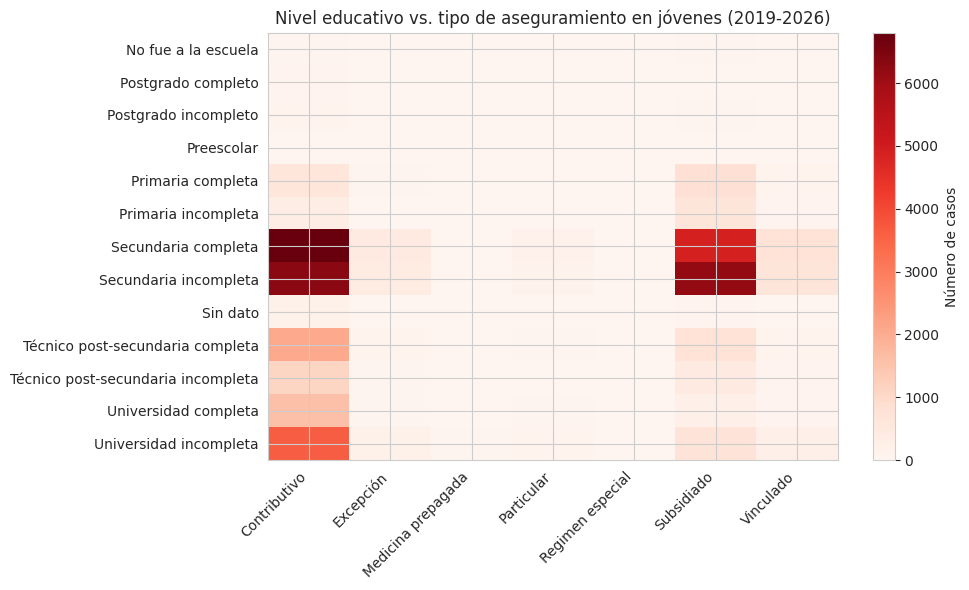

In [19]:
tabla_cruzada = pd.crosstab(
    df_jovenes['NIVELEDUCATIVO'],
    df_jovenes['TIPOASEGURAMIENTO'],
    values=df_jovenes['CASOS'],
    aggfunc='sum'
).fillna(0)

plt.figure(figsize=(10,6))
plt.imshow(tabla_cruzada, cmap='Reds', aspect='auto')
plt.colorbar(label='Número de casos')
plt.xticks(range(len(tabla_cruzada.columns)), tabla_cruzada.columns, rotation=45, ha='right')
plt.yticks(range(len(tabla_cruzada.index)), tabla_cruzada.index)
plt.title('Nivel educativo vs. tipo de aseguramiento en jóvenes (2019-2026)')
plt.tight_layout()
plt.show()

In [20]:
nivel_total = tabla_cruzada.sum(axis=1).sort_values(ascending=False)
print("--------------- Casos por nivel educativo (%) ---------------")
print(pd.DataFrame({'Casos': nivel_total, 'Porcentaje (%)': (nivel_total/total_casos*100).round(1)}))

--------------- Casos por nivel educativo (%) ---------------
                                      Casos  Porcentaje (%)
NIVELEDUCATIVO                                             
Secundaria incompleta               13669.0            33.1
Secundaria completa                 13019.0            31.5
Universidad incompleta               4876.0            11.8
Técnico post-secundaria completa     3000.0             7.3
Universidad completa                 1911.0             4.6
Técnico post-secundaria incompleta   1652.0             4.0
Primaria completa                    1522.0             3.7
Primaria incompleta                  1065.0             2.6
Sin dato                              266.0             0.6
Postgrado incompleto                  135.0             0.3
No fue a la escuela                   115.0             0.3
Postgrado completo                     87.0             0.2
Preescolar                             28.0             0.1


In [21]:
tabla_resumen = pd.DataFrame({
    "Pregunta": [
        "Localidad con más casos",
        "Año con más casos",
        "Sexo con más casos",
        "Lugar de consumo más común",
        "Nivel educativo con más casos"
    ],
    "Resultado": [
        casos_localidad.idxmax(),
        casos_anio.idxmax(),
        casos_sexo.idxmax(),
        serie_sitio.idxmax(),
        tabla_cruzada.sum(axis=1).idxmax()
    ],
    "Número de casos": [
        casos_localidad.max(),
        casos_anio.max(),
        casos_sexo.max(),
        serie_sitio.max(),
        tabla_cruzada.sum(axis=1).max()
    ]
})
tabla_resumen

,Pregunta,Resultado,Número de casos
0,Localidad con más casos,Kennedy,4624.0
1,Año con más casos,2025,7176.0
2,Sexo con más casos,Hombre,28679.0
3,Lugar de consumo más común,Vía pública,23635.0
4,Nivel educativo con más casos,Secundaria incompleta,13669.0


# **5. ANALISIS ESTADISTICO**

### 5.1 Estadística descriptiva de la variable `CASOS`

Antes de decidir cómo modelar los datos, se reviso la forma de la variable `CASOS` a nivel de fila agregada (antes de expandir).

In [22]:
print("Media               :", round(df_jovenes['CASOS'].mean(), 3))
print("Mediana             :", df_jovenes['CASOS'].median())
print("Moda                :", df_jovenes['CASOS'].mode()[0])
print("Desviacion estándar :", round(df_jovenes['CASOS'].std(), 3))
print("Mínimo / Máximo     :", df_jovenes['CASOS'].min(), "/", df_jovenes['CASOS'].max())

q1, q3 = np.percentile(df_jovenes['CASOS'], [25, 75])
iqr = q3 - q1
bigote_sup = q3 + 1.5 * iqr
atipicos = (df_jovenes['CASOS'] > bigote_sup).sum()
print("\nQ1 / Q3 / IQR                            :", q1, "/", q3, "/", iqr)
print("Bigote superior de Tukey                 :", bigote_sup)
print("Filas con CASOS atípico (regla de Tukey) :", atipicos, f"({atipicos/len(df_jovenes)*100:.1f}% de las filas)")

print("\nSkewness (asimetría)   :", round(df_jovenes['CASOS'].skew(), 2))
print("Kurtosis               :", round(df_jovenes['CASOS'].kurtosis(), 2))

Media               : 1.072
Mediana             : 1.0
Moda                : 1
Desviacion estándar : 0.366
Mínimo / Máximo     : 1 / 10

Q1 / Q3 / IQR                            : 1.0 / 1.0 / 0.0
Bigote superior de Tukey                 : 1.0
Filas con CASOS atípico (regla de Tukey) : 2007 (5.2% de las filas)

Skewness (asimetría)   : 8.08
Kurtosis               : 95.32


**Interpretación:** el 94.8% de las filas tiene `CASOS = 1`. La asimetría es extremadamente alta (8.1) y la curtosis también (95), es decir, la variable está lejísimos de una distribución normal: es una variable de conteo con una cola larga de combinaciones que agrupan varios casos. Esto se confirma con una prueba de Shapiro-Wilk sobre una muestra.

In [23]:
muestra = df_jovenes['CASOS'].sample(min(5000, len(df_jovenes)), random_state=42)
stat, p = st.shapiro(muestra)
print(f"Shapiro-Wilk: estadístico={stat:.4f}  p-valor={p:.6f}")
print("Con p < 0.05 se rechaza H0 (los datos NO son compatibles con una distribución normal).")

Shapiro-Wilk: estadístico=0.1881  p-valor=0.000000
Con p < 0.05 se rechaza H0 (los datos NO son compatibles con una distribución normal).


**Decisión metodológica:** Dado que `CASOS` es casi siempre 1 (36.578 de 38.585 filas), se puede **expandir el dataset repitiendo cada fila tantas veces como indique `CASOS`**, para pasar de un dataset agregado a uno donde cada fila representa un caso individual. Esto solo agrega 2.760 filas extra (41.345 filas en total) y resuelve el problema de que "una fila no es una persona", permitiendo aplicar los modelos de clasificación de forma correcta sobre casos individuales en lugar de combinaciones de categorías.

In [24]:
df_expandido = df_jovenes.loc[df_jovenes.index.repeat(df_jovenes['CASOS'])].reset_index(drop=True)
print("Filas antes de expandir (agregadas):", len(df_jovenes))
print("Filas después de expandir (casi-individuales):", len(df_expandido))
print("Suma de CASOS (debe coincidir con filas expandidas):", df_jovenes['CASOS'].sum())

Filas antes de expandir (agregadas): 38585
Filas después de expandir (casi-individuales): 41345
Suma de CASOS (debe coincidir con filas expandidas): 41345


### 5.2 Pruebas de hipótesis: independencia entre variables categóricas

Se usa la prueba de **chi-cuadrado de independencia** para evaluar si existe asociación estadísticamente significativa entre pares de variables categóricas clave del estudio. Como complemento, se calcula el coeficiente **V de Cramér**, que mide el tamaño del efecto (0 = sin asociación, 1 = asociación perfecta), independientemente del tamaño de la muestra.

Se define primero la variable objetivo del modelo predictivo: **LOCALIDAD_RIESGO**, que vale "Alto riesgo" si el caso reside en una de las cinco localidades con más casos (Kennedy, Bosa, Suba, Ciudad Bolívar, Engativá) y "Resto" en caso contrario.

In [25]:
def cramers_v(chi2, n, r, k):
    return np.sqrt((chi2 / n) / (min(r - 1, k - 1)))

top5 = ['Kennedy', 'Bosa', 'Suba', 'Ciudad Bolívar', 'Engativá']
df_jovenes['LOCALIDAD_RIESGO'] = df_jovenes['NOMBRELOCALIDADRESIDENCIA'].isin(top5).map({True: 'Alto riesgo', False: 'Resto'})

casos_top5 = df_jovenes.loc[df_jovenes['NOMBRELOCALIDADRESIDENCIA'].isin(top5), 'CASOS'].sum()
total = df_jovenes['CASOS'].sum()
print(f"Casos en localidades de alto riesgo: {casos_top5} ({casos_top5/total*100:.1f}%)")
print(f"Casos en el resto de localidades   : {total-casos_top5} ({(total-casos_top5)/total*100:.1f}%)")

Casos en localidades de alto riesgo: 19598 (47.4%)
Casos en el resto de localidades   : 21747 (52.6%)


In [26]:
pruebas = []

# H0.1: NIVELEDUCATIVO y TIPOASEGURAMIENTO son independientes
tabla = pd.crosstab(df_jovenes['NIVELEDUCATIVO'], df_jovenes['TIPOASEGURAMIENTO'], values=df_jovenes['CASOS'], aggfunc='sum').fillna(0)
chi2, p, dof, exp = st.chi2_contingency(tabla)
n = tabla.values.sum()
pruebas.append(('Nivel educativo vs. Tipo de aseguramiento', chi2, dof, p, cramers_v(chi2, n, *tabla.shape)))

# H0.2: SEXO y LOCALIDAD_RIESGO son independientes
tabla = pd.crosstab(df_jovenes['SEXO'], df_jovenes['LOCALIDAD_RIESGO'], values=df_jovenes['CASOS'], aggfunc='sum').fillna(0)
tabla = tabla.loc[['Hombre', 'Mujer']]
chi2, p, dof, exp = st.chi2_contingency(tabla)
n = tabla.values.sum()
pruebas.append(('Sexo vs. Localidad de riesgo', chi2, dof, p, cramers_v(chi2, n, *tabla.shape)))

# H0.3: NIVELEDUCATIVO y LOCALIDAD_RIESGO son independientes
tabla = pd.crosstab(df_jovenes['NIVELEDUCATIVO'], df_jovenes['LOCALIDAD_RIESGO'], values=df_jovenes['CASOS'], aggfunc='sum').fillna(0)
chi2, p, dof, exp = st.chi2_contingency(tabla)
n = tabla.values.sum()
pruebas.append(('Nivel educativo vs. Localidad de riesgo', chi2, dof, p, cramers_v(chi2, n, *tabla.shape)))

# H0.4: TIPOASEGURAMIENTO y LOCALIDAD_RIESGO son independientes
tabla = pd.crosstab(df_jovenes['TIPOASEGURAMIENTO'], df_jovenes['LOCALIDAD_RIESGO'], values=df_jovenes['CASOS'], aggfunc='sum').fillna(0)
chi2, p, dof, exp = st.chi2_contingency(tabla)
n = tabla.values.sum()
pruebas.append(('Tipo de aseguramiento vs. Localidad de riesgo', chi2, dof, p, cramers_v(chi2, n, *tabla.shape)))

tabla_pruebas = pd.DataFrame(pruebas, columns=['Prueba', 'Chi2', 'gl', 'p-valor', "V de Cramér"])
tabla_pruebas

,Prueba,Chi2,gl,p-valor,V de Cramér
0,Nivel educativo vs. Tipo de aseguramiento,3479.706000,72,0.000000e+00,0.118436
1,Sexo vs. Localidad de riesgo,37.127648,1,1.106437e-09,0.029973
2,Nivel educativo vs. Localidad de riesgo,200.457888,12,2.623597e-36,0.069631
3,Tipo de aseguramiento vs. Localidad de riesgo,329.082410,6,4.758396e-68,0.089216


**Interpretación:** en las cuatro pruebas el p-valor es prácticamente 0, es decir, se **rechaza la hipótesis nula de independencia** en todos los casos: sí existe asociación estadísticamente significativa entre estas variables. Sin embargo, la V de Cramér es baja en todos los casos (entre 0.03 y 0.12), lo que indica que, aunque la asociación es real, es **débil en magnitud**. Con más de 41.000 casos, hasta diferencias pequeñas resultan estadísticamente significativas, por lo que la significancia estadística no debe confundirse con relevancia práctica grande. Esto ya anticipa que un modelo basado solo en estas variables va a tener un poder predictivo moderado, no perfecto.

In [27]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve)

##**6. Selección del modelo**

**Tipo de problema:** Clasificación binaria supervisada. La variable objetivo es `LOCALIDAD_RIESGO` (1 = localidad de alto riesgo, 0 = resto), y las variables predictoras son SEXO, NIVELEDUCATIVO, TIPOASEGURAMIENTO, ANO y los seis indicadores de lugar habitual de consumo. Se excluyen `NOMBRELOCALIDADRESIDENCIA` (porque define la variable objetivo) y `NOMBREUPZ` (porque es una subdivisión geográfica de la localidad y filtraría información de la respuesta al modelo, es decir, causaría fuga de información).

**Modelos comparados** (los tres vistos en el curso para clasificación):

| Modelo | Por qué se incluye |
|---|---|
| Regresión logística | Modelo de referencia (baseline), muy interpretable, permite ver el efecto de cada variable |
| Árbol de decisión | Captura relaciones no lineales y es fácil de explicar como reglas si-entonces |
| Random Forest | Ensamble de árboles, generalmente más robusto y con mejor desempeño que un árbol individual |

Se comparan los tres con las mismas particiones de entrenamiento/prueba (80/20, estratificadas para conservar el balance de clases) y con validación cruzada de 5 pliegues, siguiendo la misma metodología usada en clase.

Se excluyen también PERTENENCIAETNICA, ORIENTSEXUAL, ESTADOCIVIL y COMOACUDIOTRATAMIENTO por no formar parte del perfil sociodemográfico definido en la pregunta del modelo predictivo.

In [28]:
sitios = ['SITIOHABITUALCONSUMO_VIVIENDA','SITIOHABITUALCONSUMO_PARQUE','SITIOHABITUALCONSUMO_EST_EDUCATIVO',
          'SITIOHABITUALCONSUMO_BARES_TABERNAS','SITIOHABITUALCONSUMO_VIA_PUBLICA','SITIOHABITUALCONSUMO_CASA_AMIGOS']

df_modelo = df_expandido.copy()
df_modelo['LOCALIDAD_RIESGO'] = df_modelo['NOMBRELOCALIDADRESIDENCIA'].isin(top5).astype(int)
for s in sitios:
    df_modelo[s] = (df_modelo[s] == 'SI').astype(int)

# Se filtra a Hombre/Mujer: Intersexual y Sin dato tienen muy pocos casos para el modelo
df_modelo = df_modelo[df_modelo['SEXO'].isin(['Hombre', 'Mujer'])].copy()

cat_cols = ['SEXO', 'NIVELEDUCATIVO', 'TIPOASEGURAMIENTO']
X = pd.get_dummies(df_modelo[cat_cols + ['ANO'] + sitios], columns=cat_cols, drop_first=True)
y = df_modelo['LOCALIDAD_RIESGO']

print("Forma de X:", X.shape)
print("\nBalance de clases (variable objetivo):")
print(y.value_counts(normalize=True).round(3))

Forma de X: (41327, 26)

Balance de clases (variable objetivo):
LOCALIDAD_RIESGO
0    0.526
1    0.474
Name: proportion, dtype: float64


**Balance de clases:** 47.4% alto riesgo / 52.6% resto. Al estar cerca de 50/50, el *accuracy* es una métrica confiable de entrada, sin necesidad de técnicas adicionales de balanceo.

##**7. Aplicación del modelo**

In [29]:
from sklearn.pipeline import make_pipeline

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

modelos = {
    'Regresión Logística': LogisticRegression(max_iter=1000, random_state=42),
    'Árbol de Decisión': DecisionTreeClassifier(max_depth=6, min_samples_leaf=30, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=300, max_depth=8, random_state=42, n_jobs=-1)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
resultados = {}
predicciones = {}

for nombre, modelo in modelos.items():
    if nombre == 'Regresión Logística':
        modelo.fit(X_train_sc, y_train)
        pred = modelo.predict(X_test_sc)
        proba = modelo.predict_proba(X_test_sc)[:, 1]
        pipeline_log = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=42))
        cv_scores = cross_val_score(pipeline_log, X, y, cv=cv, scoring='accuracy')
    else:
        modelo.fit(X_train, y_train)
        pred = modelo.predict(X_test)
        proba = modelo.predict_proba(X_test)[:, 1]
        cv_scores = cross_val_score(modelo, X, y, cv=cv, scoring='accuracy')

    resultados[nombre] = dict(
        accuracy=accuracy_score(y_test, pred),
        precision=precision_score(y_test, pred),
        recall=recall_score(y_test, pred),
        f1=f1_score(y_test, pred),
        auc=roc_auc_score(y_test, proba),
        cv_mean=cv_scores.mean(),
        cv_std=cv_scores.std(),
        cv_scores=cv_scores
    )
    predicciones[nombre] = (pred, proba)

tabla_resultados = pd.DataFrame(resultados).T[['accuracy','precision','recall','f1','auc','cv_mean','cv_std']]
tabla_resultados.columns = ['Accuracy','Precisión','Recall','F1-score','AUC','CV accuracy (media)','CV accuracy (desv.)']
tabla_resultados.round(4)

,Accuracy,Precisión,Recall,F1-score,AUC,CV accuracy (media),CV accuracy (desv.)
Regresión Logística,0.564481,0.548505,0.458908,0.499722,0.582989,0.569216,0.004671
Árbol de Decisión,0.568473,0.570567,0.362175,0.443091,0.598105,0.573983,0.003594
Random Forest,0.581418,0.577417,0.435937,0.4968,0.62147,0.583081,0.006661


##**8. Evaluación del modelo e interpretación de resultados**

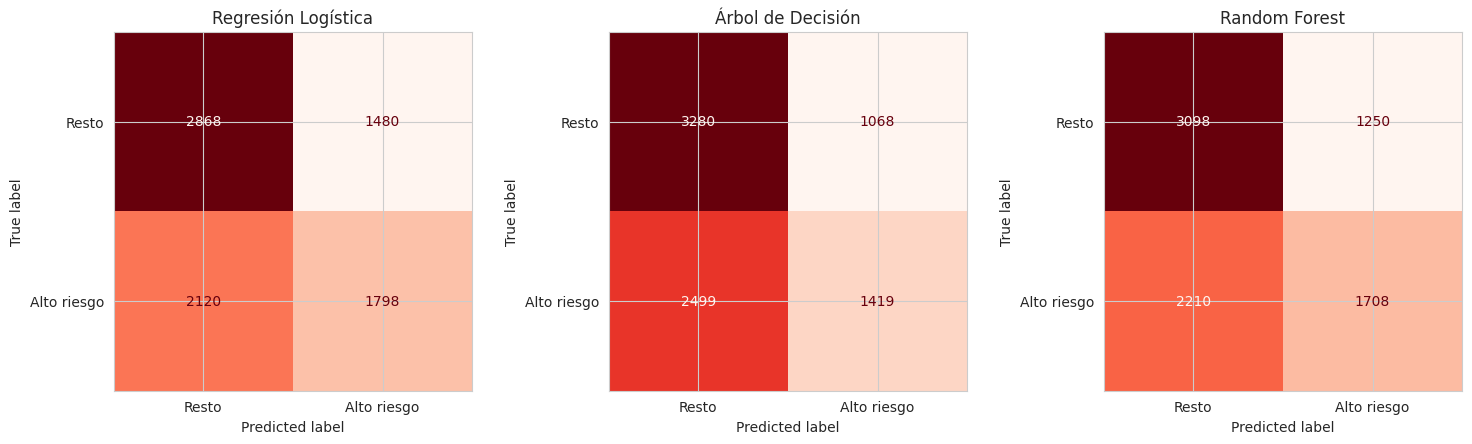

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (nombre, (pred, proba)) in zip(axes, predicciones.items()):
    ConfusionMatrixDisplay.from_predictions(y_test, pred, ax=ax, colorbar=False, cmap='Reds',
                                             display_labels=['Resto','Alto riesgo'])
    ax.set_title(nombre)
plt.tight_layout()
plt.show()

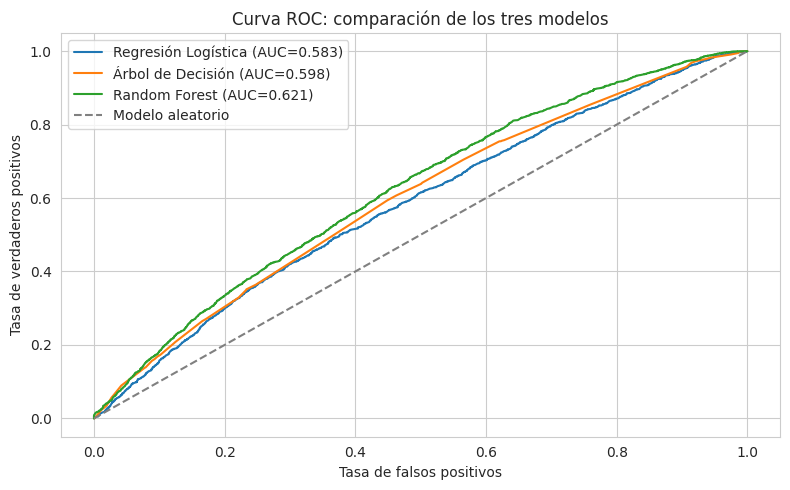

In [31]:
plt.figure(figsize=(8, 5))
for nombre, (pred, proba) in predicciones.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, label=f"{nombre} (AUC={resultados[nombre]['auc']:.3f})")
plt.plot([0,1],[0,1], linestyle='--', color='gray', label='Modelo aleatorio')
plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de verdaderos positivos')
plt.title('Curva ROC: comparación de los tres modelos')
plt.legend()
plt.tight_layout()
plt.show()

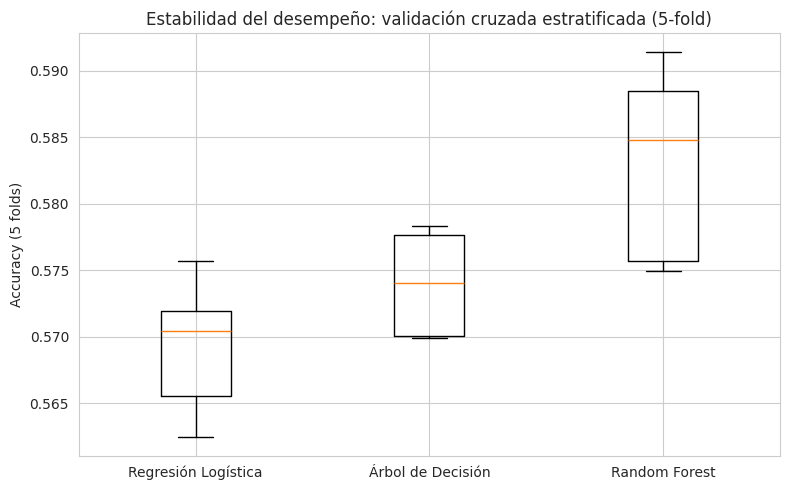

In [32]:
plt.figure(figsize=(8, 5))
datos_cv = [resultados[n]['cv_scores'] for n in modelos.keys()]
plt.boxplot(datos_cv, tick_labels=list(modelos.keys()))
plt.ylabel('Accuracy (5 folds)')
plt.title('Estabilidad del desempeño: validación cruzada estratificada (5-fold)')
plt.tight_layout()
plt.show()

**Lectura de las métricas:** Los tres modelos rondan entre 56% y 58% de *accuracy*, apenas por encima de la línea base de 52.6% (que se obtendría prediciendo siempre "resto", la clase mayoritaria). Random Forest es el que mejor generaliza (mayor *accuracy* de validación cruzada y mayor AUC), aunque por un margen modesto sobre los otros dos. La validación cruzada muestra que los tres modelos son estables (poca variación entre pliegues), así que el desempeño moderado no es cuestión de una partición de datos con mala suerte, sino un límite real de la información disponible.

Esto es coherente con lo encontrado en las pruebas de chi-cuadrado: las asociaciones son estadísticamente significativas pero de magnitud débil (V de Cramér bajo). En otras palabras, el perfil sociodemográfico de un caso (sexo, nivel educativo, aseguramiento, lugar de consumo) por sí solo no determina con fuerza la localidad de residencia. Esto tiene sentido porque la localidad de residencia depende más de dónde vive la persona (un factor geográfico y socioeconómico estructural) que de su perfil individual de consumo.

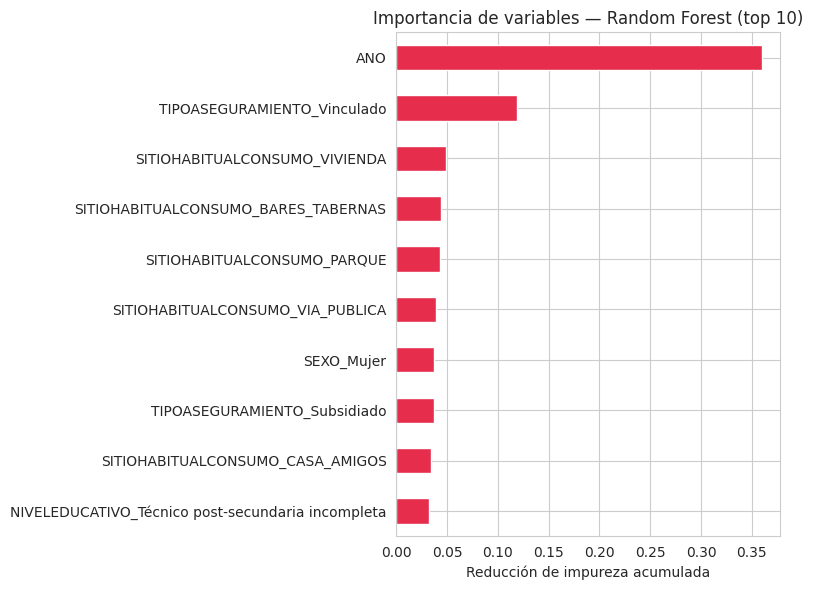

In [33]:
importancias_rf = pd.Series(modelos['Random Forest'].feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
importancias_rf.head(10).sort_values().plot(kind='barh', color='#E62E4C')
plt.title('Importancia de variables — Random Forest (top 10)')
plt.xlabel('Reducción de impureza acumulada')
plt.tight_layout()
plt.show()

**Variables más relevantes según Random Forest:** El año de notificación (`ANO`) es, por lejos, la variable más influyente, seguida del tipo de aseguramiento "Vinculado" y de varios lugares habituales de consumo (vivienda, bares/tabernas, parque, vía pública). Esto sugiere que el peso relativo de cada localidad ha ido cambiando año a año, y que el tipo de aseguramiento en salud (que suele reflejar condición socioeconómica) sí aporta información sobre el riesgo territorial, aunque de forma moderada.

Esta lectura debe tomarse con cautela: la importancia por reducción de impureza en Random Forest tiende a favorecer variables numéricas con muchos valores distintos (como ANO) frente a variables categóricas binarias, simplemente porque ofrecen más puntos de corte posibles para el algoritmo. Parte de la importancia tan alta de ANO puede deberse a este sesgo técnico y no solo a una señal real más fuerte.

##**9. MODELO COMPLEMENTARIO: PRONÓSTICO Y ALERTA TEMPRANA DE CASOS MENSUALES**

Como complemento al modelo de localidad de riesgo, se construyó un segundo modelo con un enfoque distinto: En vez de predecir ***dónde*** ocurre el riesgo, se predice ***cuándo*** (en qué mes) habrá un volumen alto de casos, usando pronóstico de series de tiempo.

=== ÚLTIMAS PREDICCIONES (PRÓXIMOS MESES) ===
            ds   yhat  yhat_lower  yhat_upper
90  2026-07-01  549.8       344.4       749.1
91  2026-08-01  560.8       364.0       757.6
92  2026-09-01  575.6       368.5       756.5
93  2026-10-01  594.8       399.5       794.5
94  2026-11-01  554.2       365.2       759.8
95  2026-12-01  496.9       312.0       698.4
96  2027-01-01  478.4       285.6       692.0
97  2027-02-01  579.4       381.0       777.6
98  2027-03-01  507.0       312.1       704.7
99  2027-04-01  511.4       321.0       703.1
100 2027-05-01  708.4       509.3       908.9
101 2027-06-01  598.1       412.2       805.0


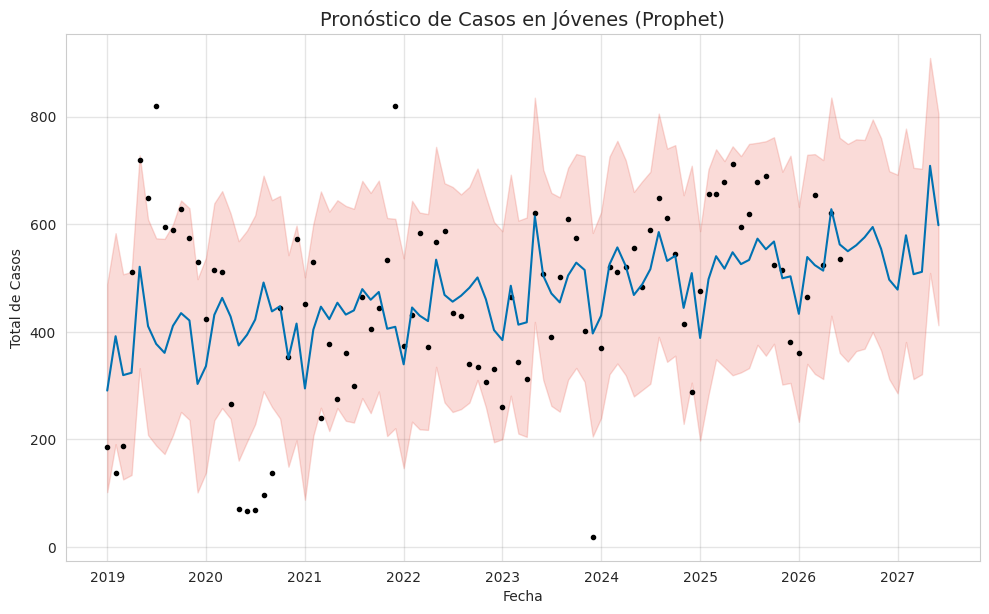

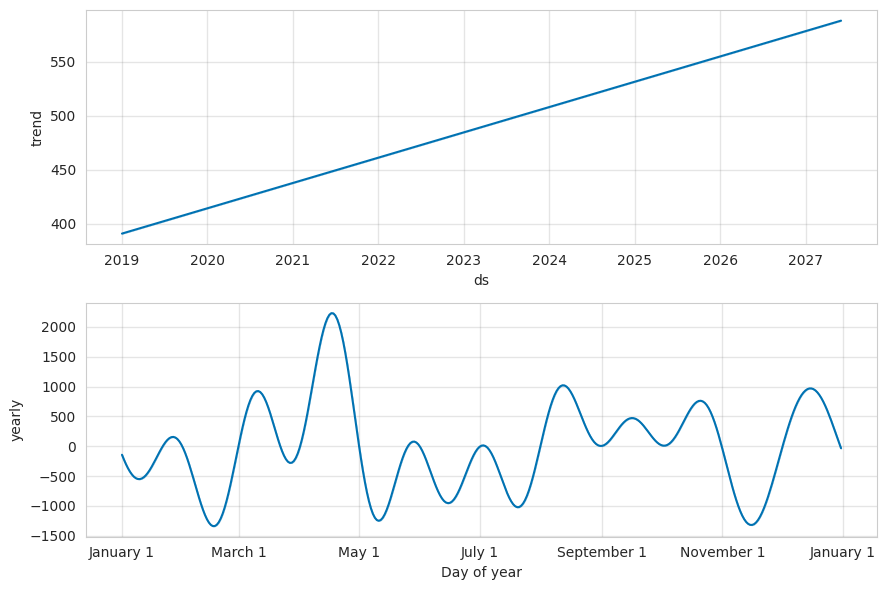

In [34]:

from prophet import Prophet

df_tiempo = (
    df_jovenes.groupby(['ANO', 'MESNOTIFICACION'])['CASOS']
    .sum()
    .reset_index()
    .sort_values(['ANO', 'MESNOTIFICACION'])
)

df_tiempo['ds'] = pd.to_datetime(
    df_tiempo['ANO'].astype(str) + '-' +
    df_tiempo['MESNOTIFICACION'].astype(str).str.zfill(2) + '-01'
)
df_tiempo['y'] = df_tiempo['CASOS']

df_prophet = df_tiempo[['ds', 'y']]

# 4. Inicializar y entrenar el modelo Prophet
# Habilitamos la estacionalidad anual explícitamente
modelo = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
modelo.fit(df_prophet)

# 5. Crear el horizonte de predicción (ejemplo: predecir los próximos 12 meses)
futuro = modelo.make_future_dataframe(periods=12, freq='MS')
pronostico = modelo.predict(futuro)

# 6. Mostrar métricas descriptivas del pronóstico
print("=== ÚLTIMAS PREDICCIONES (PRÓXIMOS MESES) ===")
print(pronostico[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(12).round(1))

# 7. Graficar los resultados del modelo
fig1 = modelo.plot(pronostico)

ax = fig1.gca()  # Obtener los ejes actuales

# A) Cambiar el color de los puntos de datos reales (negros por defecto)
for collection in ax.collections:
    collection.set_color('#E74C3C')  # Ejemplo: Rojo

plt.title('Pronóstico de Casos en Jóvenes (Prophet)', fontsize=14)
plt.xlabel('Fecha')
plt.ylabel('Total de Casos')
plt.show()

# 8. Graficar la descomposición (Tendencia + Estacionalidad)
fig2 = modelo.plot_components(pronostico)
plt.show()

La selección de Prophet para este análisis se debe a que está optimizado para series temporales con un marcado comportamiento estacional y cambios de tendencia en el tiempo.
A diferencia de modelos estadísticos tradicionales (como ARIMA) que exigen transformaciones complejas de los datos, o redes neuronales que requieren miles de registros, Prophet modela la serie temporal de forma intuitiva y flexible:

* Maneja la estacionalidad de forma nativa: Captura de manera precisa patrones repetitivos anuales (picos o caídas en meses específicos) mediante series de Fourier.

* Tolera irregularidades: Es resistente a datos faltantes, valores atípicos y cambios en la frecuencia de notificación.

* Detección de puntos de cambio: Identifica de forma automática momentos del pasado donde la tendencia cambió su dirección o velocidad y la proyecta al futuro.

* Resultados interpretables: Genera intervalos de confianza claros (límites superior e inferior), lo que facilita la toma de decisiones basada en escenarios probables y no solo en un valor único.

In [35]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from prophet import Prophet

# 1. Preparar datos temporales agregados
df_eval = (
    df_jovenes.groupby(['ANO', 'MESNOTIFICACION'])['CASOS']
    .sum()
    .reset_index()
    .sort_values(['ANO', 'MESNOTIFICACION'])
)

df_eval['ds'] = pd.to_datetime(
    df_eval['ANO'].astype(str) + '-' +
    df_eval['MESNOTIFICACION'].astype(str).str.zfill(2) + '-01'
)
df_eval['y'] = df_eval['CASOS']

# Crear variables numéricas de tiempo para los modelos de ML
df_eval['num_mes'] = df_eval['ds'].dt.month
df_eval['num_ano'] = df_eval['ds'].dt.year
df_eval['tiempo_index'] = np.arange(len(df_eval))

# 2. Split cronológico: Guardar los últimos 12 meses para TEST
corte = len(df_eval) - 12
train = df_eval.iloc[:corte].copy()
test = df_eval.iloc[corte:].copy()

# Variables explicativas para ML y Variable Objetivo
features = ['num_mes', 'num_ano', 'tiempo_index']
X_train, y_train = train[features], train['y']
X_test, y_test = test[features], test['y']

# 3. Entrenar los 4 modelos
# A) Regresión Lineal
lr = LinearRegression().fit(X_train, y_train)
pred_lr = lr.predict(X_test)

# B) Árbol de Decisión
dt = DecisionTreeRegressor(max_depth=5, random_state=42).fit(X_train, y_train)
pred_dt = dt.predict(X_test)

# C) Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42).fit(X_train, y_train)
pred_rf = rf.predict(X_test)

# D) Prophet
m_prophet = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
m_prophet.fit(train[['ds', 'y']])
future = m_prophet.make_future_dataframe(periods=12, freq='MS')
forecast = m_prophet.predict(future)
pred_prophet = forecast.iloc[corte:]['yhat'].clip(lower=0).values

# 4. Tabla de Comparación de Errores
modelos_eval = {
    'Regresión Lineal': pred_lr,
    'Árbol de Decisión': pred_dt,
    'Random Forest': pred_rf,
    'Prophet': pred_prophet
}

resultados = {}
for nombre, pred in modelos_eval.items():
    resultados[nombre] = {
        'MAE (Error en casos)': mean_absolute_error(y_test, pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, pred)),
        'R2 Score': r2_score(y_test, pred)
    }

df_comparativa = pd.DataFrame(resultados).T
print("=== COMPARATIVA DE ERROR EN EL PRONÓSTICO DE CASOS ===")
print(df_comparativa.round(2))

=== COMPARATIVA DE ERROR EN EL PRONÓSTICO DE CASOS ===
                   MAE (Error en casos)    RMSE  R2 Score
Regresión Lineal                  86.46  107.05     -0.05
Árbol de Decisión                 97.25  117.00     -0.26
Random Forest                     88.93  114.93     -0.21
Prophet                           79.96   97.51      0.13


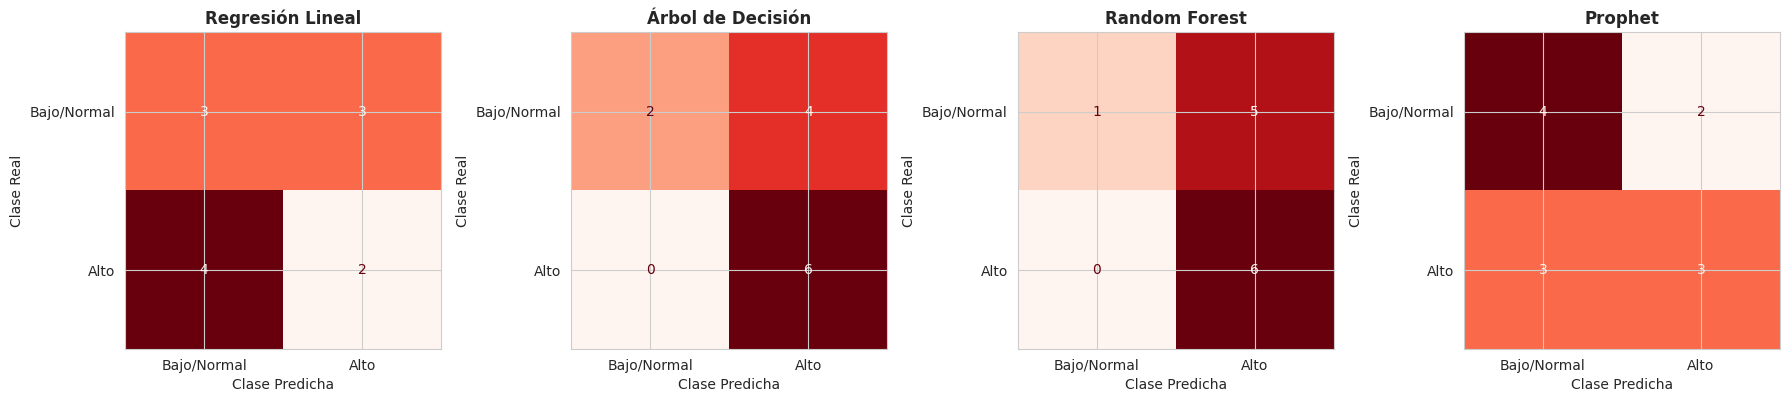

In [36]:
# 1. Preparar datos temporales agregados
df_eval = (
    df_jovenes.groupby(['ANO', 'MESNOTIFICACION'])['CASOS']
    .sum()
    .reset_index()
    .sort_values(['ANO', 'MESNOTIFICACION'])
)

df_eval['ds'] = pd.to_datetime(
    df_eval['ANO'].astype(str) + '-' +
    df_eval['MESNOTIFICACION'].astype(str).str.zfill(2) + '-01'
)
df_eval['y'] = df_eval['CASOS']

# Crear variables numéricas de tiempo para los modelos de ML
df_eval['num_mes'] = df_eval['ds'].dt.month
df_eval['num_ano'] = df_eval['ds'].dt.year
df_eval['tiempo_index'] = np.arange(len(df_eval))

# 2. Split cronológico: Guardar los últimos 12 meses para TEST
corte = len(df_eval) - 12
train = df_eval.iloc[:corte].copy()
test = df_eval.iloc[corte:].copy()

# Variables explicativas para ML y Variable Objetivo
features = ['num_mes', 'num_ano', 'tiempo_index']
X_train, y_train = train[features], train['y']
X_test, y_test = test[features], test['y']

# 3. Entrenar los 4 modelos
# A) Regresión Lineal
lr = LinearRegression().fit(X_train, y_train)
pred_lr = lr.predict(X_test)

# B) Árbol de Decisión
dt = DecisionTreeRegressor(max_depth=5, random_state=42).fit(X_train, y_train)
pred_dt = dt.predict(X_test)

# C) Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42).fit(X_train, y_train)
pred_rf = rf.predict(X_test)

# D) Prophet
m_prophet = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
m_prophet.fit(train[['ds', 'y']])
future = m_prophet.make_future_dataframe(periods=12, freq='MS')
forecast = m_prophet.predict(future)
pred_prophet = forecast.iloc[corte:]['yhat'].clip(lower=0).values

modelos_eval = {
    'Regresión Lineal': pred_lr,
    'Árbol de Decisión': pred_dt,
    'Random Forest': pred_rf,
    'Prophet': pred_prophet
}

# 4. Definir umbral sobre el periodo de prueba (Test) para detectar picos atípicos
# Se clasifica como 'Alto' si los casos superan la mediana del año de evaluación
umbral = y_test.median()

# Categorizar los valores reales (0: Bajo/Normal, 1: Alto volumen)
y_test_cat = (y_test >= umbral).astype(int)

# 5. Graficar las Matrices de Confusión corregidas
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

for ax, (nombre, pred) in zip(axes, modelos_eval.items()):
    # Categorizar la predicción del modelo con respecto al mismo umbral
    pred_cat = (pred >= umbral).astype(int)

    # Calcular y dibujar la matriz
    cm = confusion_matrix(y_test_cat, pred_cat, labels=[0, 1])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Bajo/Normal', 'Alto'])
    disp.plot(ax=ax, cmap='Reds', colorbar=False)

    # Métricas rápidas
    ax.set_title(nombre, fontsize=12, fontweight='bold')
    ax.set_xlabel('Clase Predicha')
    ax.set_ylabel('Clase Real')

plt.tight_layout()
plt.show()

Random Forest (El mejor clasificador aquí):Aciertos: Identifica correctamente 6 de 6 meses con volumen "Alto" (sensibilidad/recall perfecto del 100%).Falsos Positivos: Solo se equivoca clasificando 5 meses normales como "Alto".Total aciertos: $1 + 6 = 7$ de 12 meses correctos ($58.3\%$ accuracy).
Random Forest o Árbol de Decisión: Tienen Recall/Sensibilidad = 1.0 (100%) para la clase "Alto". En salud pública, es el indicador más crítico porque garantiza 0 falsos negativos (ningún brote pasa desapercibido).Descarta Prophet para esta tarea categórica: Su tasa de falsos negativos ($50\%$ de los meses de alto riesgo no detectados) lo hace deficiente si la meta es categorizar alertas.